In [ ]:
# !pip install xgboost imbalanced-learn streamlit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve

In [ ]:
# Load dataset (Download creditcard.csv from Kaggle)
df = pd.read_csv('creditcard.csv')

# Quick look at the class imbalance
print(df['Class'].value_counts(normalize=True))

Class
0.0    0.997118
1.0    0.002882
Name: proportion, dtype: float64


# **Exploratory Data Analysis (EDA)**

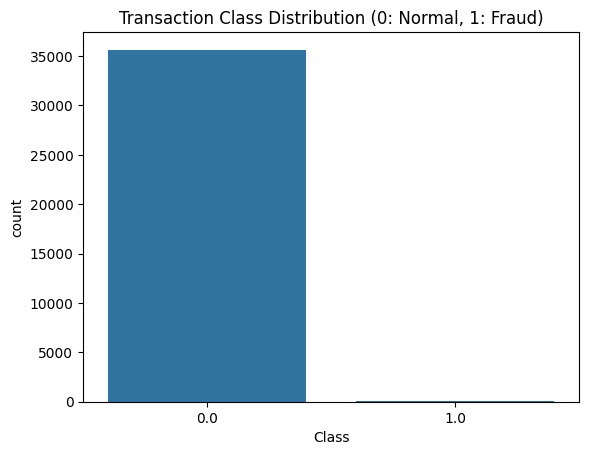

In [ ]:
# Visualizing the distribution of classes
sns.countplot(x='Class', data=df)
plt.title('Transaction Class Distribution (0: Normal, 1: Fraud)')
plt.show()

In [ ]:
# Scaling Time and Amount (V1-V28 are already scaled by PCA)
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)

In [ ]:
# Using 0.1% as the expected fraud rate (contamination)
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)
X = df.drop('Class', axis=1)
y_pred_iso = iso_forest.fit_predict(X)

In [ ]:
# Map -1 (anomaly) to 1 and 1 (normal) to 0 for comparison
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

In [ ]:
print(f"Number of NaN values in 'Class' before dropping: {df['Class'].isnull().sum()}")

Number of NaN values in 'Class' before dropping: 1


In [ ]:
df.dropna(subset=['Class'], inplace=True)
print(f"Number of NaN values in 'Class' after dropping: {df['Class'].isnull().sum()}")

Number of NaN values in 'Class' after dropping: 0


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (35741, 30)
Shape of target (y): (35741,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (28592, 30)
Shape of X_test: (7149, 30)
Shape of y_train: (28592,)
Shape of y_test: (7149,)


In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(X_train_res, y_train_res)

print("SMOTE applied and XGBoost model trained.")

SMOTE applied and XGBoost model trained.


In [ ]:
y_pred = model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


# **Evalution metrics**

Confusion Matrix:
 [[7114    4]
 [   2   29]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7118
         1.0       0.88      0.94      0.91        31

    accuracy                           1.00      7149
   macro avg       0.94      0.97      0.95      7149
weighted avg       1.00      1.00      1.00      7149

ROC AUC Score: 0.9995422780955143


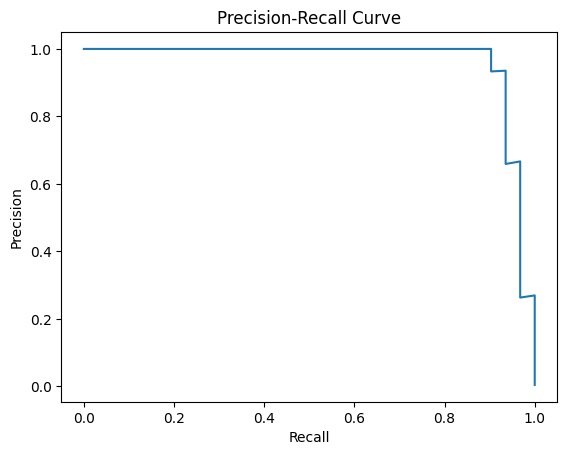

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
import joblib
import os

# Create a directory for models if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Save the XGBoost Model
joblib.dump(model, 'models/fraud_detection_model.pkl')

# 2. Save the Scaler (CRITICAL: You must scale inputs the same way you scaled training data)
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and Scaler saved successfully in /models folder!")

In [ ]:
import joblib

# Load the saved components
loaded_model = joblib.load('models/fraud_detection_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

# Example: Predicting a single new transaction
# Assume 'new_data' is a 2D array of the transaction features
# new_data_scaled = loaded_scaler.transform(new_data)
# prediction = loaded_model.predict(new_data_scaled)

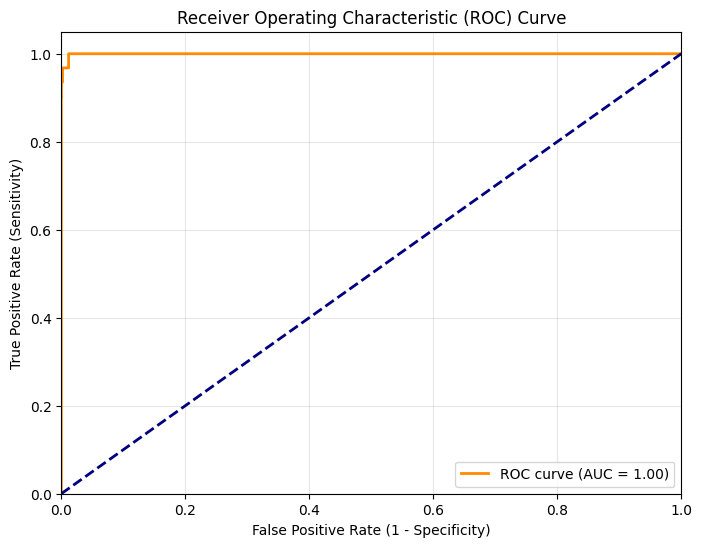

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get the predicted probabilities for the positive class (Fraud)
# model.predict_proba returns [prob_class_0, prob_class_1]
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Calculate the False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 3. Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# 4. Plotting the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

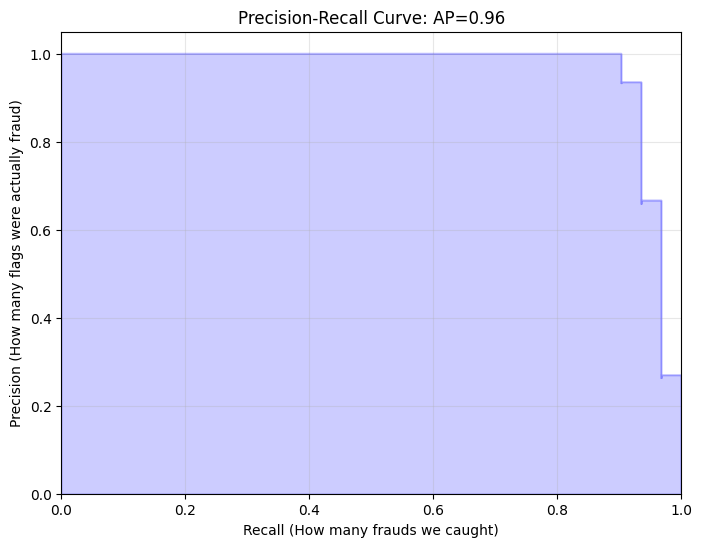

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calculate precision and recall for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 2. Calculate the Average Precision (AP)
average_precision = average_precision_score(y_test, y_probs)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (How many frauds we caught)')
plt.ylabel('Precision (How many flags were actually fraud)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Precision-Recall Curve: AP={average_precision:.2f}')
plt.grid(alpha=0.3)
plt.show()